---
format: html
echo: False
warnings: False
---

# Reporte de laboratorio 1

::: {content-hidden}
# Librerias a importar
:::

# Practica de laboratorio 1

## Introducción

En el competitivo mundo del comercio electrónico, la startup **E-ComPro** ha emergido como un innovador disruptor en el mercado. Fundada en 2018, la compañía nació de la visión de sus cofundadores, un equipo de ingenieros financieros y expertos en tecnología, quienes identificaron una necesidad insatisfecha: conectar consumidores con productos exclusivos mediante una experiencia de compra optimizada por inteligencia artificial y análisis de datos.

Desde su lanzamiento, E-ComPro ha logrado expandirse rápidamente gracias a su enfoque en marketing digital y personalización basada en datos. La empresa invierte de manera agresiva en estrategias de adquisición de clientes, buscando maximizar su retorno sobre inversión (ROI) en campañas publicitarias. Sin embargo, el equipo directivo se enfrenta a un desafío clave: **optimizar su estrategia de marketing para mejorar la rentabilidad y la retención de clientes**.

Para tomar decisiones estratégicas informadas, la junta directiva ha solicitado un análisis detallado de indicadores clave de rendimiento (KPIs), en particular:

- **Costo de Adquisición de Clientes (CAC)**: Para entender cuánto le cuesta a la empresa adquirir un nuevo cliente.
- **Valor de Vida del Cliente (LTV)**: Para estimar el ingreso promedio generado por cada cliente durante su relación con la empresa.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

**Costo de adquisición de Clientes(CAC):**
- Fórmula: $CAC = \frac{\text{Gastos en Marketing y Ventas}}{\text{Número de Clientes Nuevos}}$
- Indicador de cuánto cuesta adquirir un cliente.
- Ejemplo: Si te cuesta $10,000MXN adquirir 200 clientes, su CAC es de $50MXN

**Live time value (LTV)**
- Fórmula: $LTV = \frac{\text{Ingresos Totales de los Primeros 24 Meses de la vida de los clientes}}{\text{Clientes con 24 meses de tenure}}$
- Expresa cual es la recuperación o el retorno de inversión en valores monetarios de un cliente desde su entrada hasta 24 meses despues.
- Ejemplo: Si un cliente entro el 1/01/2020 y se suman todas sus compras siguientes hasta el 01/01/2022 se obtendría el LIV

In [3]:
def calculo_cac(marketing_expense : float, num_customer : float) -> float:
    """
    summary: Calculo de adquisión por cliente (CAC)

    Args:
        - marketing_expense (float): Costos de adqusisión del cliente
        - num_customer (float): numero de clientes

    Returns:
        float: CAC
    """
    
    CAC = marketing_expense/num_customer
    
    return CAC


In [4]:
customers_id = pd.read_csv('./resource/04_customer_ids.csv')
purchases = pd.read_csv('./resource/04_purchases.csv')
marketing_expenses = pd.read_csv('./resource/04_marketing_expenses.csv')

In [5]:
customers_id.head(5)

,customer_id,join_date
0,1000,2020-05
1,1001,2019-03
2,1002,2018-08
3,1003,2019-09
4,1004,2019-07


In [6]:
purchases.head(5)

,customer_id,purchase_date,purchase_amount
0,1000,2020-12,380.786751
1,1001,2021-01,137.592776
2,1001,2020-05,331.312056
3,1001,2019-04,114.376910
4,1002,2020-05,150.824205


In [7]:
marketing_expenses.head(5)

,month,marketing_expense
0,2018-01,5524.693974
1,2018-02,7818.313887
2,2018-03,7096.517853
3,2018-04,4557.292041
4,2018-05,5372.740000


In [ ]:
# El comdo output se utiliza para incluir una celda en la salida del programa.
# En esta caso queremo que no se muestre esta celda.
#| output: False
customers_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  300 non-null    int64 
 1   join_date    300 non-null    object
dtypes: int64(1), object(1)
memory usage: 4.8+ KB


In [9]:
#| output: False
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      1544 non-null   int64  
 1   purchase_date    1544 non-null   object 
 2   purchase_amount  1544 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 36.3+ KB


In [10]:
#| output: False
marketing_expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   month              36 non-null     object 
 1   marketing_expense  36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


### Unión de datasets

Integrar datos necesarios para el análisis

In [6]:

# El metodo merge opera con el algebra de conjuntos como si se tuviera la operación
# A u B, conde A es el data set que invoca el metodo merge y B es el data set que
# se pasa como argumento.
# On: es el campo sobre el cual se realizara la operación de conjuntos
# how: es la operación sobre la que se realiza si sera una diferencia de conjuntos
# A \ B o B \ A o A intersection B
customers_purchases = purchases.merge(customers_id, on='customer_id', how = 'left')
customers_purchases.head()

,customer_id,purchase_date,purchase_amount,join_date
0,1000,2020-12,380.786751,2020-05
1,1001,2021-01,137.592776,2019-03
2,1001,2020-05,331.312056,2019-03
3,1001,2019-04,114.376910,2019-03
4,1002,2020-05,150.824205,2018-08


## Calculo KPIs

### Costo de adquisisipon de clientes

In [7]:
# Agrupando del data set de los clientes por su fecha (mes) de entrada y contandolos
nuevos_clientes = customers_id.groupby('join_date').count()
nuevos_clientes.head(2)

,customer_id
join_date,
2018-01,8
2018-02,13


In [8]:
# Renombrando la columna sobre la cual realizaremos el join
marketing_expenses.rename(columns={'month' : 'join_date'}, inplace=True)
marketing_expenses.head(2)

,join_date,marketing_expense
0,2018-01,5524.693974
1,2018-02,7818.313887


In [9]:
# Calculando el CAC

## Realizando el join sobre los datos
cac_table = marketing_expenses.join(nuevos_clientes, on='join_date')

## Aplicando la función del calculo del CAC
cac_table['CAC'] = calculo_cac(cac_table['marketing_expense'],cac_table['customer_id'])

#Redondear el resultado a dos decimales
cac_table['CAC'] = cac_table['CAC'].round(2)

cac_table.head(5)

,join_date,marketing_expense,customer_id,CAC
0,2018-01,5524.693974,8,690.59
1,2018-02,7818.313887,13,601.41
2,2018-03,7096.517853,11,645.14
3,2018-04,4557.292041,7,651.04
4,2018-05,5372.740000,5,1074.55


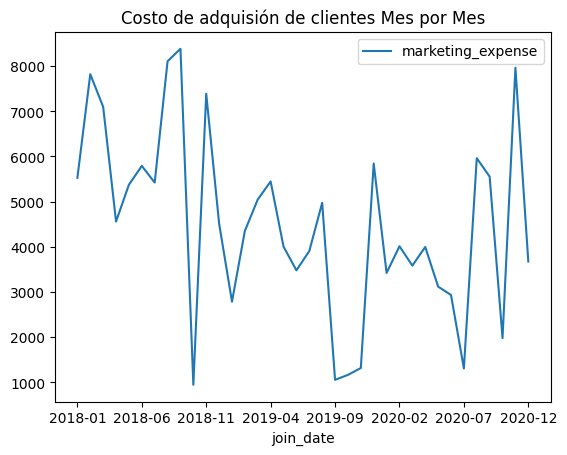

In [10]:
cac_table.plot(x='join_date', y='marketing_expense', title = 'Costo de adquisión de clientes Mes por Mes')
plt.show()

### Live time value 

In [11]:
customers_purchases['tenure'] = (
    pd.to_datetime(customers_purchases['purchase_date']).dt.to_period("M") - pd.to_datetime(customers_purchases['join_date']).dt.to_period("M")
).apply(lambda x : x.n)

Ltv_24_months = customers_purchases[customers_purchases['tenure'] <= 24]

In [13]:
Ltv_24_months.head(5)

,customer_id,purchase_date,purchase_amount,join_date,tenure
0,1000,2020-12,380.786751,2020-05,7
1,1001,2021-01,137.592776,2019-03,22
2,1001,2020-05,331.312056,2019-03,14
3,1001,2019-04,114.376910,2019-03,1
4,1002,2020-05,150.824205,2018-08,21


In [17]:
customer_ltv = Ltv_24_months.groupby('customer_id')['purchase_amount'].sum()

In [18]:
customer_ltv.head()

customer_id
1000     380.786751
1001     583.281742
1002    2286.811107
1003    2062.970211
1004    2773.921671
Name: purchase_amount, dtype: float64

#### Live time value promedio

<Axes: title={'center': 'LTV Promedio por Cohort'}, xlabel='join_date'>

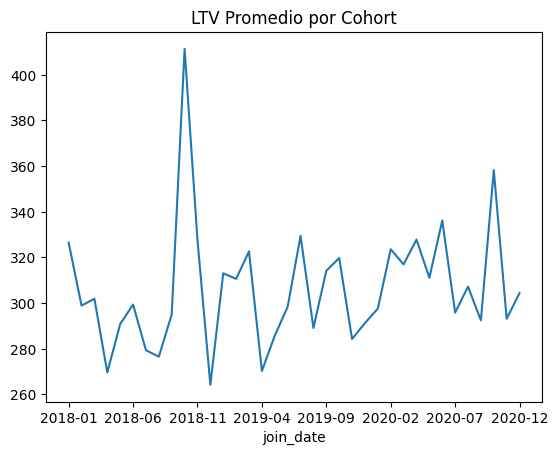

In [20]:
cohort_ltv = Ltv_24_months.groupby('join_date')['purchase_amount'].mean()
cohort_ltv.plot(title='LTV Promedio por Cohort')

### Cliente con mayor LTV

In [21]:
top_customer = customer_ltv.idxmax()
print(f"El cliente con mayor LTV es: {top_customer}")

El cliente con mayor LTV es: 1025


### Cohort con mayor LTV promedio

In [22]:
top_cohort = cohort_ltv.idxmax()
print(f"El cohort con mayor LTV promedio es: {top_cohort}")

El cohort con mayor LTV promedio es: 2018-10


## Propuesta para reducir el CAC y aumentar el LTV

### **Reducir el CAC: Optimizar la Inversión y Aumentar la Conversión**  
Para disminuir el **Costo de Adquisición de Cliente (CAC)**, es fundamental optimizar los canales de marketing enfocándose en los que generan mejor retorno. Implementa segmentación avanzada en publicidad digital, prioriza estrategias de referidos con incentivos atractivos y automatiza procesos de captación para reducir costos operativos. Además, mejora la conversión en el sitio web mediante optimización UX/UI y pruebas A/B en campañas de remarketing. **Actúa ahora y ajusta tu inversión publicitaria para atraer más clientes con menos gasto.**

### **Aumentar el LTV: Fidelización y Maximización del Valor del Cliente**  
Para elevar el **Valor de Vida del Cliente (LTV)**, es clave fomentar la recurrencia de compra y el ticket promedio. Desarrolla un programa de lealtad que premie a los clientes recurrentes, incorpora estrategias de **cross-selling y upselling** personalizadas, y optimiza el servicio postventa para mejorar la retención. Usa análisis de datos para segmentar clientes y ofrecer promociones relevantes. **Toma acción hoy mismo y convierte cada cliente en una relación de alto valor para la empresa.**